In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
# 設置中文字體
font = FontProperties(fname='msjh.ttc')

In [17]:
def generate_mixed_gaussian_data(n_samples=1000):
    np.random.seed(42)

    # 第一個群組：較為集中的群組
    n1 = int(n_samples * 0.3)
    X1 = np.random.multivariate_normal([2, 2], [[0.5, 0], [0, 0.5]], n1)

    # 第二個群組：稍微橢圓形的群組，與第三個群組有些重疊
    n2 = int(n_samples * 0.3)
    X2 = np.random.multivariate_normal([6, 2], [[1.5, 0.5], [0.5, 0.8]], n2)

    # 第三個群組：與第二個群組有部分重疊
    n3 = n_samples - n1 - n2
    X3 = np.random.multivariate_normal([4, 4], [[1.2, -0.4], [-0.4, 1.2]], n3)

    # 組合所有數據
    X = np.vstack([X1, X2, X3])
    y_true = np.array([0] * n1 + [1] * n2 + [2] * n3)

    # 打亂數據順序
    idx = np.random.permutation(n_samples)
    return X[idx], y_true[idx]

# 生成新的數據
X, y_true = generate_mixed_gaussian_data(1000)

In [18]:
# 訓練 scikit-learn 的 GMM
gmm = GaussianMixture(n_components=3, max_iter=200, tol=1e-7, random_state=42)
y_pred_gmm = gmm.fit_predict(X)

# 訓練 K-means
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred_kmeans = kmeans.fit_predict(X)

In [19]:
# 創建網格點以繪製等高線
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 計算 GMM 的密度
Z_gmm = np.exp(gmm.score_samples(grid_points))
Z_gmm = Z_gmm.reshape(xx.shape)

# 計算 K-means 的決策邊界
Z_kmeans = kmeans.predict(grid_points).reshape(xx.shape)

Text(0, 0.5, 'Y')

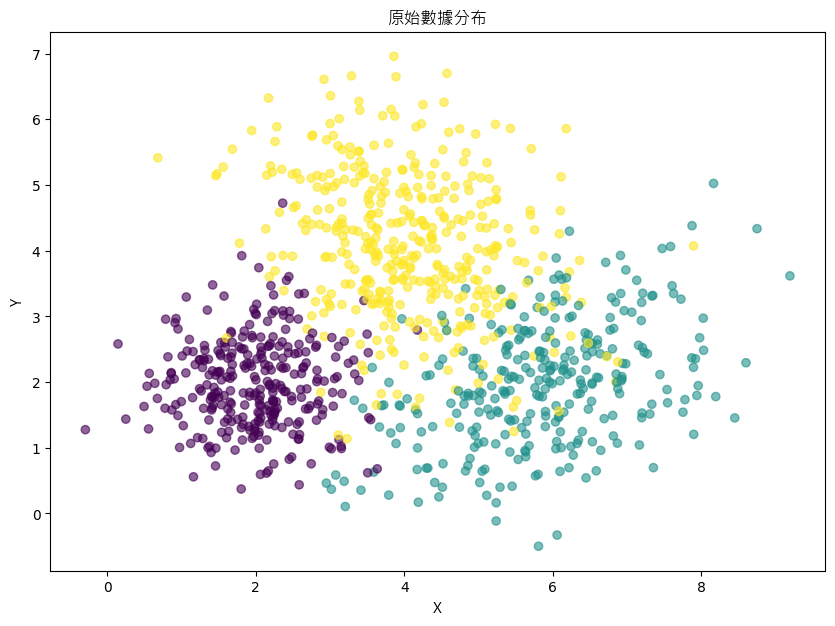

In [20]:
# 1. 原始數據分布
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6)
plt.title('原始數據分布', fontproperties=font, fontsize=12)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)

Text(0, 0.5, 'Y')

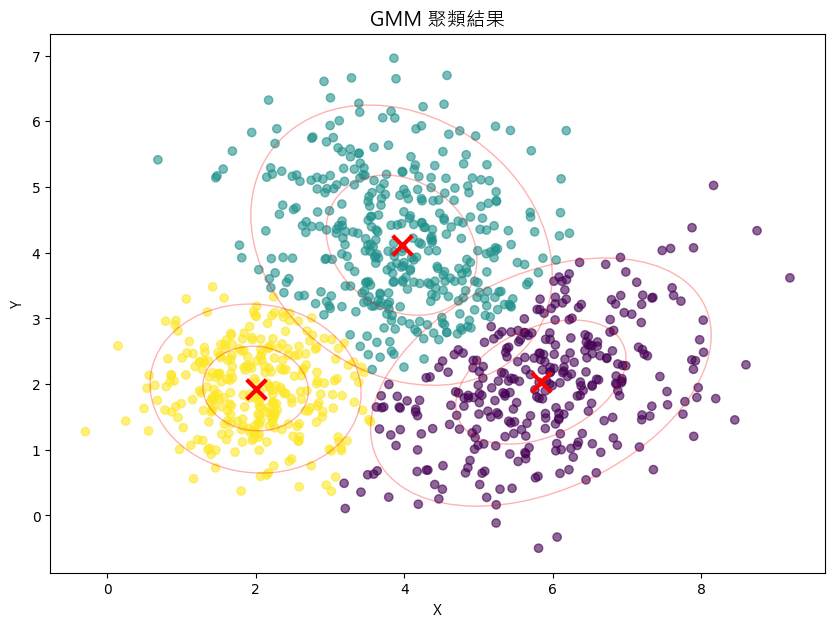

In [21]:
# 2. GMM 聚類結果 (散點圖)
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_pred_gmm, cmap='viridis', alpha=0.6)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', marker='x', s=200, linewidth=3)
# 繪製 GMM 的協方差橢圓
for k in range(gmm.n_components):
    eigenvals, eigenvecs = np.linalg.eigh(gmm.covariances_[k])
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    for nstd in [1, 2]:
        ell = plt.matplotlib.patches.Ellipse(
            gmm.means_[k], 2*nstd*np.sqrt(eigenvals[0]),
            2*nstd*np.sqrt(eigenvals[1]),
            angle=angle, color='red', fill=False, alpha=0.3
        )
        plt.gca().add_patch(ell)

plt.title('GMM 聚類結果', fontproperties=font, fontsize=14)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)

Text(0, 0.5, 'Y')

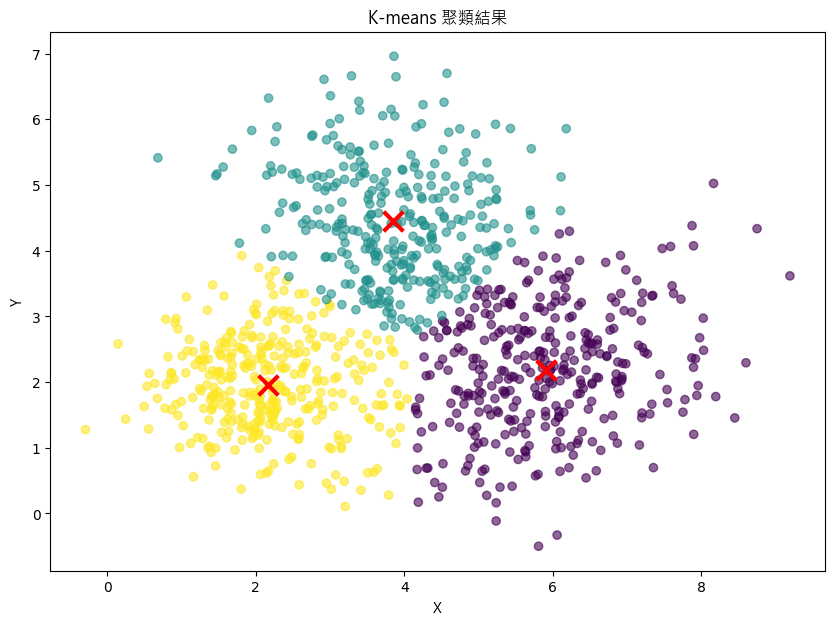

In [22]:
# 3. K-means 聚類結果 (散點圖)
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_pred_kmeans, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           c='red', marker='x', s=200, linewidth=3)
plt.title('K-means 聚類結果', fontproperties=font, fontsize=12)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)

Text(0, 0.5, 'Y')

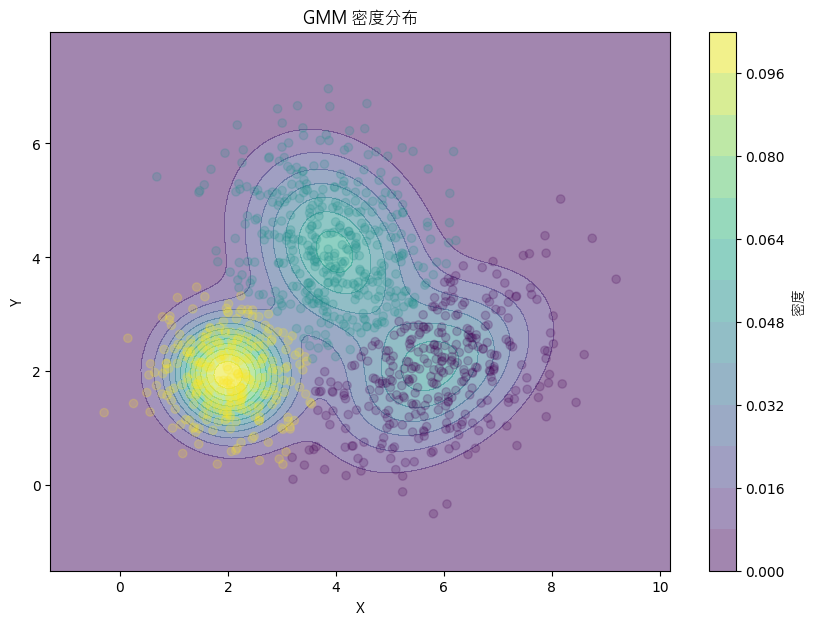

In [23]:
# 4. GMM 密度等高線圖
plt.figure(figsize=(10, 7))
contour_gmm = plt.contourf(xx, yy, Z_gmm, levels=15, cmap='viridis', alpha=0.5)
plt.colorbar(contour_gmm, label='密度').set_label('密度', fontproperties=font)
plt.scatter(X[:, 0], X[:, 1], c=y_pred_gmm, cmap='viridis', alpha=0.2)
plt.title('GMM 密度分布', fontproperties=font, fontsize=12)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)

Text(0, 0.5, 'Y')

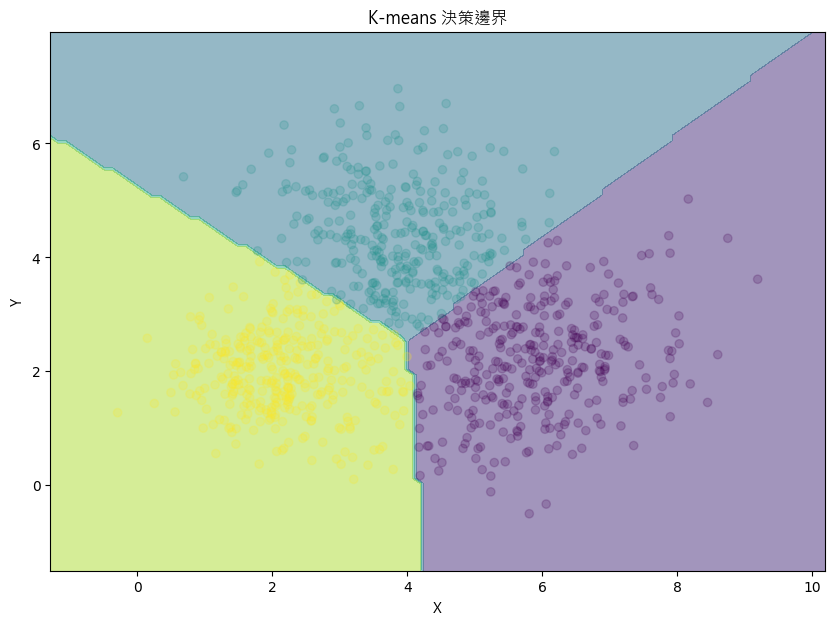

In [24]:
# 5. K-means 決策邊界
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_kmeans, levels=3, cmap='viridis', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y_pred_kmeans, cmap='viridis', alpha=0.2)
plt.title('K-means 決策邊界', fontproperties=font, fontsize=12)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)

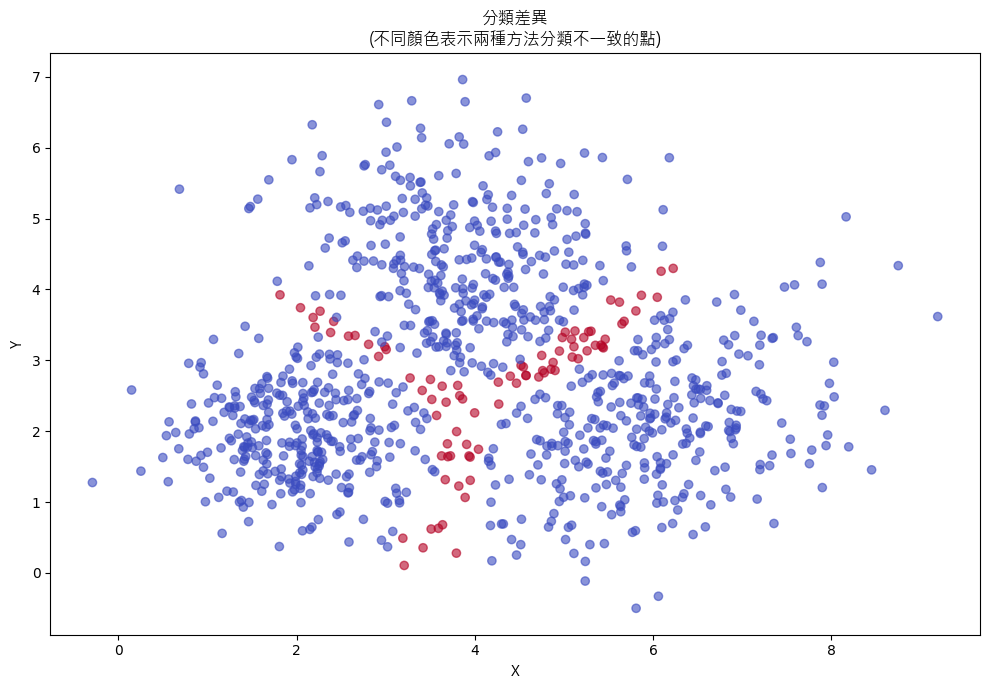

In [25]:
# 6. 兩種方法的分類差異
plt.figure(figsize=(10, 7))
diff = (y_pred_gmm != y_pred_kmeans).astype(int)
plt.scatter(X[:, 0], X[:, 1], c=diff, cmap='coolwarm', alpha=0.6)
plt.title('分類差異\n(不同顏色表示兩種方法分類不一致的點)',
         fontproperties=font, fontsize=12)
plt.xlabel('X', fontproperties=font)
plt.ylabel('Y', fontproperties=font)
plt.tight_layout()
plt.show()

In [26]:
# 輸出兩種方法的比較結果
from sklearn.metrics.cluster import adjusted_mutual_info_score

# 計算與真實標籤的調整互信息分數
ami_gmm = adjusted_mutual_info_score(y_true, y_pred_gmm)
ami_kmeans = adjusted_mutual_info_score(y_true, y_pred_kmeans)

print("\n聚類效果評估:")
print(f"GMM 調整互信息分數: {ami_gmm:.3f}")
print(f"K-means 調整互信息分數: {ami_kmeans:.3f}")


聚類效果評估:
GMM 調整互信息分數: 0.723
K-means 調整互信息分數: 0.651
